### Oracle Evaluation Table and Plots

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

root = Path("out_real/all3oracle")
folds = [1, 2, 3, 4, 5]
methods = ["homo", "binwise", "hetero"]
skip = 200
target = 0.90

def series(method, fold, fname):
    a = np.loadtxt(root / f"all3cv{fold}oracle" / method / fname).reshape(-1)
    return a[skip:]

rows = []

for m in methods:
    z_mean, z_under, z_q05, z_med = [], [], [], []
    nz_mean, nz_under, nz_q05, nz_med = [], [], [], []

    for f in folds:
        z = series(m, f, "conformal_coverages_zero.txt")
        nz = series(m, f, "conformal_coverages_nz.txt")

        z_mean.append(z.mean())
        z_under.append(np.mean(z < target))
        z_q05.append(np.quantile(z, 0.05))
        z_med.append(np.median(z))

        nz_mean.append(nz.mean())
        nz_under.append(np.mean(nz < target))
        nz_q05.append(np.quantile(nz, 0.05))
        nz_med.append(np.median(nz))

    rows.append({
        "Method": m,

        "NZ cov (mean ± sd)":
            f"{np.mean(nz_mean):.3f} ± {np.std(nz_mean):.3f}",
        "NZ cov (median)":
            f"{np.mean(nz_med):.3f}",
        "P(NZcov_t < 0.9)":
            f"{np.mean(nz_under):.3f}",
        "NZ cov 5th pct":
            f"{np.mean(nz_q05):.3f}",

        "Z cov (mean ± sd)":
            f"{np.mean(z_mean):.3f} ± {np.std(z_mean):.3f}",
        "Z cov (median)":
            f"{np.mean(z_med):.3f}",
        "P(Zcov_t < 0.9)":
            f"{np.mean(z_under):.3f}",
        "Z cov 5th pct":
            f"{np.mean(z_q05):.3f}",
    })

df = pd.DataFrame(rows)
df

,Method,NZ cov (mean ± sd),NZ cov (median),P(NZcov_t < 0.9),NZ cov 5th pct,Z cov (mean ± sd),Z cov (median),P(Zcov_t < 0.9),Z cov 5th pct
0,homo,0.914 ± 0.003,0.913,0.307,0.862,0.900 ± 0.000,0.899,0.507,0.818
1,binwise,0.912 ± 0.001,0.915,0.283,0.864,0.899 ± 0.000,0.900,0.500,0.816
2,hetero,0.926 ± 0.003,0.960,0.209,0.700,0.900 ± 0.000,0.908,0.446,0.784


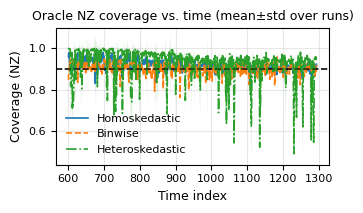

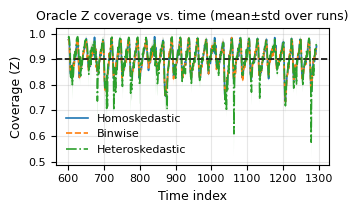

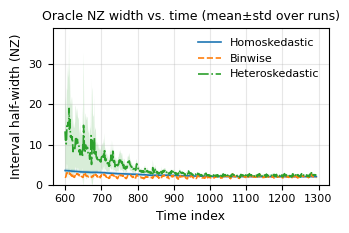

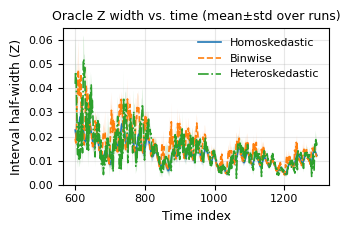

Saved figures to: /home/x54g559/UncertaintySSMF/figs_oracle_cv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Config
# ============================================================
plt.rcParams.update({
    "font.size": 9,            # base font size
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.titlesize": 9,
})

FIG_W = 3.5    # inches
FIG_H = 2.2    # inches (coverage)
FIG_H_W = 2.4  # inches (width, needs more vertical space)



root = Path("out_real/all3oracle")

folds = [1, 2, 3, 4, 5]
methods = ["homo", "binwise", "hetero"]
METHOD_LABELS = {
    "homo":    "Homoskedastic",
    "binwise": "Binwise",
    "hetero":  "Heteroskedastic",
}


# Burn-in (skip first N time steps)
skip = 600          

# Coverage target (for horizontal line)
target = 0.90

# Summary band over folds: "iqr" or "std"
summary = "std"     # "iqr" = median + IQR band, "std" = mean ± std band

# Log toggles for width plots
use_log_width_nz = False
use_log_width_z  = False

# Floors for log scaling (choose for readability)
nz_width_floor = 1e-2
z_width_floor  = 1e-6   # only used if use_log_width_z = True

# If width can contain zeros, clip slightly for log plots
eps_width = 1e-12

# Output
OUTDIR = Path("figs_oracle_cv")
OUTDIR.mkdir(parents=True, exist_ok=True)

SAVE_PDF = True
SAVE_PNG = True
PNG_DPI  = 300

# What to plot (sanity-check all vs. only widths)
PLOT_COVERAGE = True
PLOT_WIDTH    = True

# Style: make lines distinguishable without relying on color only
STYLE = {
    "homo":    dict(linestyle="-"),
    "binwise": dict(linestyle="--"),
    "hetero":  dict(linestyle="-."),
}

# ============================================================
# I/O helpers
# ============================================================
FILES = {
    "cov_nz": "conformal_coverages_nz.txt",
    "cov_z":  "conformal_coverages_zero.txt",
    "wid_nz": "conformal_widths_nz.txt",
    "wid_z":  "conformal_widths_zero.txt",
}

def load_1d(path: Path):
    """Load a 1D float array from a txt file; return None if missing."""
    if not path.exists():
        return None
    arr = np.loadtxt(path, dtype=float)
    arr = np.asarray(arr, dtype=float).reshape(-1)
    return arr

def trim(arr, skip):
    """Trim burn-in; return None if too short."""
    if arr is None or len(arr) <= skip:
        return None
    return arr[skip:]

# ============================================================
# Data assembly
# all_data[method][key] -> ndarray shape (n_folds, T) or None
# ============================================================
all_data = {m: {k: [] for k in FILES} for m in methods}

# Load fold series
for m in methods:
    for f in folds:
        d = root / f"all3cv{f}oracle" / m
        for key, fname in FILES.items():
            arr = trim(load_1d(d / fname), skip=skip)
            all_data[m][key].append(arr)

# Convert lists to aligned 2D arrays (n_folds, T), trimming to min T
for m in methods:
    for key in FILES:
        seq = [a for a in all_data[m][key] if a is not None]
        if len(seq) == 0:
            all_data[m][key] = None
            continue
        T = min(len(a) for a in seq)
        mat = np.vstack([a[:T] for a in seq])  # shape: (folds, T)
        all_data[m][key] = mat

def make_time_axis(any_key):
    """Create x-axis for a metric, using the first available method."""
    for m in methods:
        mat = all_data[m].get(any_key, None)
        if mat is not None:
            T = mat.shape[1]
            # original time index after burn-in
            return np.arange(skip, skip + T)
    return None

# ============================================================
# Plotting helpers
# ============================================================
def band_stats(Y, kind="iqr"):
    """
    Y: (F, T) array
    kind: 'iqr' -> median + [q25,q75]
          'std' -> mean + [mean-std, mean+std]
    Returns (center, lo, hi)
    """
    if kind == "iqr":
        center = np.nanmedian(Y, axis=0)
        lo = np.nanpercentile(Y, 25, axis=0)
        hi = np.nanpercentile(Y, 75, axis=0)
        return center, lo, hi
    elif kind == "std":
        center = np.nanmean(Y, axis=0)
        sd = np.nanstd(Y, axis=0)
        return center, center - sd, center + sd
    else:
        raise ValueError("kind must be 'iqr' or 'std'")

def plot_band(ax, x, Y, *, method, label, band_kind="iqr", target_line=None, is_width=False):
    """
    Plot fold summary band + center line.
    Y: (F,T)
    """
    center, lo, hi = band_stats(Y, kind=band_kind)

    if is_width:
        # widths should be nonnegative; also protect log plots
        lo = np.maximum(lo, eps_width)
        hi = np.maximum(hi, eps_width)
        center = np.maximum(center, eps_width)

    st = STYLE.get(method, {})
    ax.plot(x, center, label=label, linestyle=st.get("linestyle", "-"), linewidth=1.2)
    ax.fill_between(x, lo, hi, alpha=0.18)

    if target_line is not None:
        ax.axhline(target_line, linestyle="--", color="k", alpha=0.5, linewidth=1.2)


def save_fig(fig, stem):
    """Save as PDF/PNG with tight bbox."""
    if SAVE_PDF:
        fig.savefig(OUTDIR / f"{stem}.pdf", bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(OUTDIR / f"{stem}.png", dpi=PNG_DPI, bbox_inches="tight")

# ============================================================
# 1) Coverage plots (NZ and Z) — separate figures
# ============================================================
if PLOT_COVERAGE:
    # --- NZ Coverage ---
    x = make_time_axis("cov_nz")
    if x is None:
        raise RuntimeError("Could not infer time axis for NZ coverage.")
    fig, ax = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))

    for m in methods:
        Y = all_data[m]["cov_nz"]
        if Y is None:
            continue
        plot_band(
            ax, x, Y,
            method=m,
            label=METHOD_LABELS[m],
            band_kind=summary,
            target_line=target,
            is_width=False
        )

    ax.set_ylabel("Coverage (NZ)")
    ax.set_xlabel("Time index")
    ax.set_title(f"Oracle NZ coverage vs. time ({'median/IQR' if summary=='iqr' else 'mean±std'} over runs)")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left", frameon=False)

    plt.tight_layout()
    save_fig(fig, f"oracle_cov_NZ_skip{skip}_{summary}")
    plt.show()

    # --- Z Coverage ---
    x = make_time_axis("cov_z")
    if x is None:
        raise RuntimeError("Could not infer time axis for Z coverage.")
    fig, ax = plt.subplots(1, 1, figsize=(FIG_W, FIG_H))

    for m in methods:
        Y = all_data[m]["cov_z"]
        if Y is None:
            continue
        plot_band(
            ax, x, Y,
            method=m,
            label=METHOD_LABELS[m],
            band_kind=summary,
            target_line=target,
            is_width=False
        )
    ax.set_ylabel("Coverage (Z)")
    ax.set_xlabel("Time index")
    ax.set_title(f"Oracle Z coverage vs. time ({'median/IQR' if summary=='iqr' else 'mean±std'} over runs)")
    ax.grid(alpha=0.3)
    ax.legend(loc="lower left", frameon=False)

    plt.tight_layout()
    save_fig(fig, f"oracle_cov_Z_skip{skip}_{summary}")
    plt.show()

# ============================================================
# 2) Width plots (NZ and Z) — separate figures (publication-ready)
# ============================================================
if PLOT_WIDTH:
    # --- NZ Width ---
    x = make_time_axis("wid_nz")
    if x is None:
        raise RuntimeError("Could not infer time axis for NZ width.")
    fig, ax = plt.subplots(1, 1, figsize=(FIG_W, FIG_H_W))

    for m in methods:
        Y = all_data[m]["wid_nz"]
        if Y is None:
            continue
        plot_band(ax, x, Y, method=m, label=METHOD_LABELS[m], band_kind=summary, target_line=None, is_width=True)

        
    ax.set_ylabel("Interval half-width (NZ)")
    ax.set_xlabel("Time index")
    ax.set_title(f"Oracle NZ width vs. time ({'median/IQR' if summary=='iqr' else 'mean±std'} over runs)")
    if use_log_width_nz:
        ax.set_yscale("log")
        ax.set_ylim(bottom=nz_width_floor)
    else:
        ax.set_ylim(bottom=0.0)
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    save_fig(fig, f"oracle_width_NZ_skip{skip}_{summary}_{'log' if use_log_width_nz else 'lin'}")
    plt.show()

    # --- Z Width ---
    x = make_time_axis("wid_z")
    if x is None:
        raise RuntimeError("Could not infer time axis for Z width.")
    fig, ax = plt.subplots(1, 1, figsize=(FIG_W, FIG_H_W))

    for m in methods:
        Y = all_data[m]["wid_z"]
        if Y is None:
            continue
        plot_band(ax, x, Y, method=m, label=METHOD_LABELS[m], band_kind=summary, target_line=None, is_width=True)
    ax.set_ylabel("Interval half-width (Z)")
    ax.set_xlabel("Time index")
    ax.set_title(f"Oracle Z width vs. time ({'median/IQR' if summary=='iqr' else 'mean±std'} over runs)")
    if use_log_width_z:
        ax.set_yscale("log")
        ax.set_ylim(bottom=max(eps_width, z_width_floor))
    else:
        ax.set_ylim(bottom=0.0)  # optionally set top if you want: , top=0.15
    ax.grid(alpha=0.3, which="both")
    ax.legend(loc="upper right", frameon=False)

    plt.tight_layout()
    save_fig(fig, f"oracle_width_Z_skip{skip}_{summary}_{'log' if use_log_width_z else 'lin'}")
    plt.show()

print(f"Saved figures to: {OUTDIR.resolve()}")